# **PROJEK UTS BUSINESS INTELLIGENCE - FOOD DELIVERY DATASET**

Kelompok:

- **Dafa Firdaus**
- **Muhammad Romadhoni Alfatih**
- **Muhammad Rifqi Jastiartha**

# **Food Delivery BI Project — Data Warehouse**

Perkembangan layanan food delivery semakin meningkat seiring pertumbuhan platform digital. Data delivery dapat dimanfaatkan untuk menganalisis performa pengiriman, perilaku pelanggan, dan efisiensi layanan. Oleh karena itu, diperlukan pembangunan data warehouse untuk membantu proses analisis data dan pengambilan keputusan bisnis.

# **TAHAPAN PROSES YANG DILAKUKAN**


1. Pengumpulan dataset dari **Kaggle**
2. Data cleaning
3. Transformasi data
4. Pembuatan Data Warehouse
5. Analisis data
6. Visualisasi hasil analisis
7. Upload project ke **GitHub**

# **ETL PROCESS**

🔹 Extract
- Dataset diambil dari Kaggle
- Format CSV

🔹 Transform

- Menghapus missing value
- Mengubah format tanggal
- Memisahkan kategori waktu
- Mengubah tipe data numerik

🔹 Load

- Data dimasukkan ke dalam Data Warehouse
- Menggunakan struktur Star Schema

# **DATA WAREHOUSE DESIGN**

# **Fact Table**

- fact_delivery

| delivery_id | customer_id | time_id | location_id | total_order | delivery_time |




# **Dimension Table**

- **dim_customer**

| customer_id | customer_name | customer_rating |

- **dim_time**

| time_id | day | month | year | hour |

- **dim_location**

| location_id | city | area |

# **Import Library & Load Dataset**

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/test_df.csv')
df.head()

,Unnamed: 0,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,...,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0,0xc62d,LUDHRES04DEL02,31.0,4.7,30.914057,75.839820,30.934057,75.859820,17-02-2022,...,08:35:00,Windy,Low,1.0,Drinks,motorcycle,1.0,No,Metropolitian,28.0
1,1,0x3118,BANGRES03DEL02,36.0,4.4,12.979166,77.640709,12.999166,77.660709,01-03-2022,...,09:25:00,Windy,Low,0.0,Drinks,motorcycle,0.0,No,Metropolitian,29.0
2,2,0x6e9d,CHENRES03DEL01,28.0,4.0,13.091809,80.219104,13.131809,80.259104,15-03-2022,...,13:45:00,Stormy,High,0.0,Buffet,motorcycle,1.0,No,Metropolitian,32.0
3,3,0x528f,CHENRES18DEL01,34.0,4.2,12.981615,80.231598,13.021615,80.271598,05-03-2022,...,12:45:00,Sandstorms,High,0.0,Drinks,motorcycle,2.0,No,Metropolitian,37.0
4,4,0x99d0,COIMBRES16DEL01,26.0,4.8,11.010375,76.952950,11.080375,77.022950,02-03-2022,...,20:35:00,Windy,Jam,2.0,Meal,scooter,0.0,No,Urban,29.0


In [18]:
df.describe()

,Unnamed: 0,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Vehicle_condition,multiple_deliveries,Time_taken(min),Month,Hour
count,4137.000000,4137.000000,4137.000000,4137.000000,4137.000000,4137.000000,4137.000000,4137,4137.000000,4137.000000,4137.000000,4137.000000,4137.0
mean,2068.000000,29.395697,4.639715,17.204698,70.643490,17.389792,70.707089,2022-03-13 09:32:56.214648320,0.989848,0.736766,26.631375,2.965917,0.0
min,0.000000,20.000000,2.600000,-27.161850,0.000000,0.010000,0.010000,2022-02-11 00:00:00,0.000000,0.000000,10.000000,2.000000,0.0
25%,1034.000000,24.000000,4.500000,12.933298,73.751081,12.989096,73.785750,2022-03-04 00:00:00,0.000000,0.000000,19.000000,3.000000,0.0
50%,2068.000000,29.000000,4.700000,18.546947,76.276999,18.622718,76.303136,2022-03-15 00:00:00,1.000000,1.000000,26.000000,3.000000,0.0
75%,3102.000000,34.000000,4.800000,22.744648,78.049117,22.793659,78.108890,2022-03-26 00:00:00,2.000000,1.000000,33.000000,3.000000,0.0
max,4136.000000,39.000000,5.000000,30.914057,88.433452,31.039584,88.563187,2022-04-06 00:00:00,2.000000,3.000000,54.000000,4.000000,0.0
std,1194.393361,5.773222,0.301762,7.682832,21.437558,7.406530,21.437572,NaN,0.821256,0.564577,9.316626,0.541819,0.0


# **Data Cleaning**

In [5]:
df.isnull().sum()

df = df.dropna()

In [17]:
df.dtypes

,0
Unnamed: 0,int64
ID,object
Delivery_person_ID,object
Delivery_person_Age,float64
Delivery_person_Ratings,float64
Restaurant_latitude,float64
Restaurant_longitude,float64
Delivery_location_latitude,float64
Delivery_location_longitude,float64
Order_Date,datetime64[ns]


# **Transformasi Data**

In [10]:
city_orders = df.groupby('City').size()

city_orders.sort_values(ascending=False).head(10)

,0
City,
Metropolitian,3191
Urban,927
Semi-Urban,19


# **ANALISIS DATA**

## **Average Delivery Time**

In [25]:
avg_delivery = df['Time_taken(min)'].mean()

print("Rata-rata delivery time:", round(avg_delivery, 2), "menit")

Rata-rata delivery time: 26.63 menit


## **Kota dengan Order Terbanyak**

In [19]:
city_orders = df.groupby('City').size()

city_orders.sort_values(ascending=False)

,0
City,
Metropolitian,3191
Urban,927
Semi-Urban,19


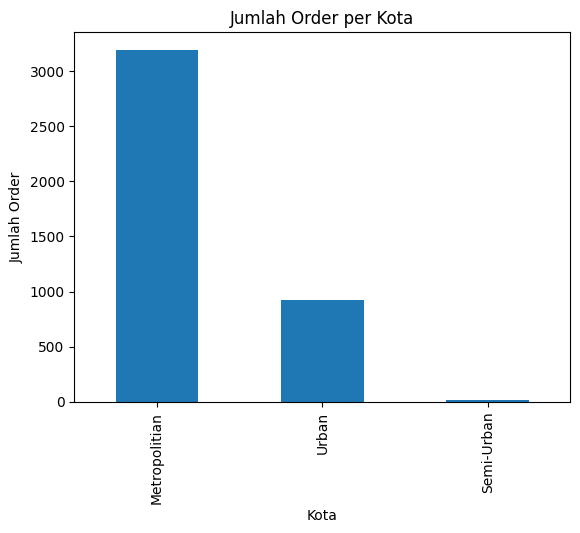

In [28]:
city_orders.sort_values(ascending=False).plot(kind='bar')

plt.title('Jumlah Order per Kota')
plt.xlabel('Kota')
plt.ylabel('Jumlah Order')

plt.show()


Kota dengan jumlah order tertinggi menunjukkan tingkat permintaan layanan delivery yang lebih besar dibanding kota lainnya.

## **Cuaca vs Delivery Time**

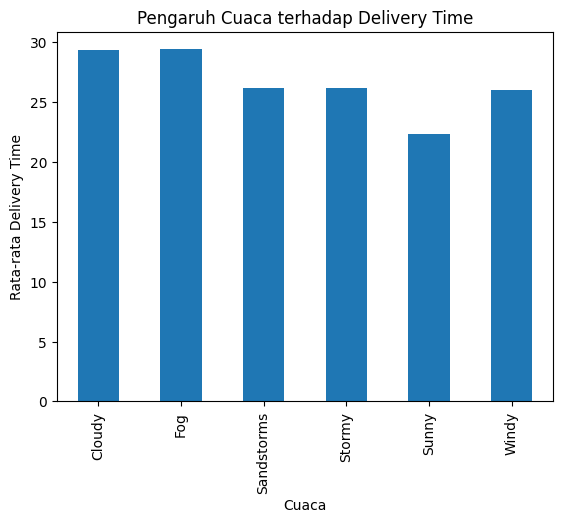

In [22]:
weather_delivery = df.groupby('Weatherconditions')['Time_taken(min)'].mean()

weather_delivery.plot(kind='bar')

plt.title('Pengaruh Cuaca terhadap Delivery Time')
plt.xlabel('Cuaca')
plt.ylabel('Rata-rata Delivery Time')

plt.show()

Kondisi cuaca tertentu menyebabkan peningkatan waktu pengiriman. Hal ini menunjukkan bahwa faktor lingkungan memiliki pengaruh terhadap efisiensi proses delivery.

## **Traffic vs Delivery Time**

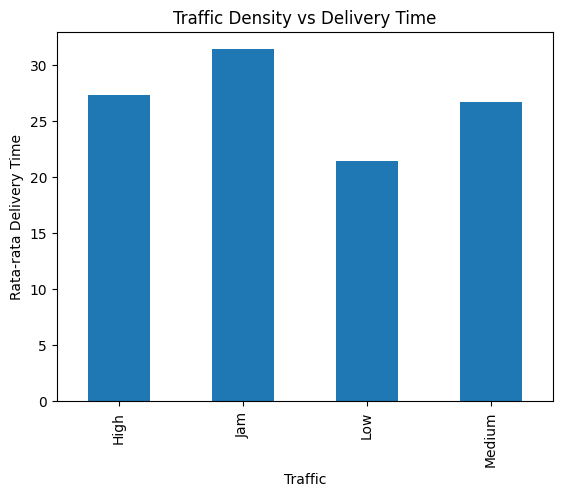

In [23]:
traffic_delivery = df.groupby('Road_traffic_density')['Time_taken(min)'].mean()

traffic_delivery.plot(kind='bar')

plt.title('Traffic Density vs Delivery Time')
plt.xlabel('Traffic')
plt.ylabel('Rata-rata Delivery Time')

plt.show()

Semakin tinggi tingkat kepadatan lalu lintas, maka waktu pengiriman cenderung meningkat. Traffic menjadi salah satu faktor utama yang mempengaruhi keterlambatan delivery.

## **Rating Driver vs Delivery Time**

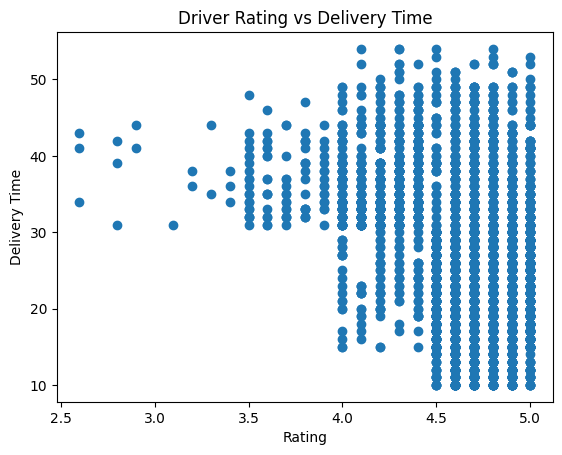

In [26]:
plt.scatter(df['Delivery_person_Ratings'], df['Time_taken(min)'])

plt.title('Driver Rating vs Delivery Time')
plt.xlabel('Rating')
plt.ylabel('Delivery Time')

plt.show()

Driver dengan rating yang lebih tinggi cenderung memiliki waktu pengiriman yang lebih stabil dan efisien. Hal ini menunjukkan adanya hubungan antara kualitas pelayanan driver dan performa delivery.

## **Export Clean Dataset**

In [32]:
df.to_csv('clean_delivery_data.csv', index=False)